# 03 - Double Machine Learning (econml)

DML (Chernozhukov, Chetverikov, Demirer, Duflo, Hansen, Newey & Robins, Econometrics Journal 2018): cross-fit nuisance models $\hat m(x) = \mathbb{E}[Y \mid X]$ and $\hat e(x) = \Pr(T=1 \mid X)$, form out-of-fold residuals, and regress $\tilde Y_i = \tau(X_i)\,\tilde T_i + \varepsilon_i$ (Robinson partialling-out, as in the R-Learner of notebook 01). Cross-fitting plus Neyman orthogonality is what makes inference valid with ML nuisances. The three variants below differ only in the final stage; all share the same LightGBM nuisances and 5-fold cross-fitting.

## Setup

In [1]:
ARTIFACT_NAME = '03_dml'
import time, warnings, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from criteo_data import fetch_criteo
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000

print('Loading Criteo...')
ds = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = ds.data, ds.target, ds.treatment
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

strat = treat_full.values * 2 + y_full.values
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat,
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

results = {}
qini_curves = {}

def evaluate(name, scores, elapsed):
    s = np.asarray(scores).flatten()
    row = {
        'AUUC':       round(uplift_auc_score(y_test, s, t_test), 6),
        'Qini':       round(qini_auc_score(y_test, s, t_test),   6),
        'Uplift@10%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.2), 4),
        'Time(s)':    round(elapsed, 1),
    }
    results[name] = row
    qini_curves[name] = s
    print(f'[{name:<28}]  Qini={row["Qini"]:.6f}  @10%={row["Uplift@10%"]:.4f}  @20%={row["Uplift@20%"]:.4f}  time={row["Time(s)"]}s')
    return row


Loading Criteo...


Train: 400,000  Test: 100,000


### Nuisance models

Because econml's DML residualizes raw $Y$, the outcome nuisance is an `LGBMRegressor` even though $Y$ is binary; propensity uses `LGBMClassifier` with `discrete_treatment=True` so econml uses `predict_proba`.

In [2]:
from lightgbm import LGBMClassifier, LGBMRegressor
from econml.dml import LinearDML, SparseLinearDML, CausalForestDML

# Shared nuisance models - outcome is binary, treatment is binary
def make_outcome():
    return LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         num_leaves=63, min_child_samples=50,
                         random_state=SEED, n_jobs=-1, verbose=-1)
def make_propensity():
    return LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                          num_leaves=63, min_child_samples=50,
                          random_state=SEED, n_jobs=-1, verbose=-1)
print('Nuisance factories ready.')

Nuisance factories ready.


## 1. LinearDML

OLS final stage on the cross-fitted residuals: $\hat\tau(x) = \hat\theta^\top x$, with valid asymptotic standard errors on every coefficient. A linear final stage averages out non-linear or interaction-driven heterogeneity.

In [3]:
t0 = time.time()
linear_dml = LinearDML(
    model_y=make_outcome(),
    model_t=make_propensity(),
    discrete_treatment=True,
    cv=5, random_state=SEED,
)
linear_dml.fit(y_train, t_train, X=X_train)
tau = linear_dml.effect(X_test).flatten()
evaluate('LinearDML', tau, time.time() - t0)

[LinearDML                   ]  Qini=0.169127  @10%=0.0113  @20%=0.0053  time=35.1s


{'AUUC': 0.005682,
 'Qini': 0.169127,
 'Uplift@10%': 0.0113,
 'Uplift@20%': 0.0053,
 'Time(s)': 35.1}

## 2. SparseLinearDML

Debiased-Lasso final stage: sparse linear CATE with valid CIs. Criteo has only 12 features, so this mostly behaves like LinearDML with extra L1 shrinkage; it stays in as a coefficient-recovery diagnostic against the SHAP ranking from notebook 00.

In [4]:
t0 = time.time()
sparse_dml = SparseLinearDML(
    model_y=make_outcome(),
    model_t=make_propensity(),
    discrete_treatment=True,
    cv=5, random_state=SEED,
)
sparse_dml.fit(y_train, t_train, X=X_train)
tau = sparse_dml.effect(X_test).flatten()
evaluate('SparseLinearDML', tau, time.time() - t0)

[SparseLinearDML             ]  Qini=0.185848  @10%=0.0125  @20%=0.0053  time=215.0s


{'AUUC': 0.006249,
 'Qini': 0.185848,
 'Uplift@10%': 0.0125,
 'Uplift@20%': 0.0053,
 'Time(s)': 215.0}

## 3. CausalForestDML

Same cross-fitted residualization with a GRF final stage: captures non-linear, interaction-driven heterogeneity and exposes `effect_interval` for pointwise CIs via the bootstrap-of-little-bags. `n_estimators=200` and `min_samples_leaf=200` are conservative defaults for ~500K rows.

In [5]:
t0 = time.time()
cf_dml = CausalForestDML(
    model_y=make_outcome(),
    model_t=make_propensity(),
    discrete_treatment=True,
    n_estimators=200, min_samples_leaf=200,
    cv=5, random_state=SEED, n_jobs=-1,
)
cf_dml.fit(y_train, t_train, X=X_train)
tau = cf_dml.effect(X_test).flatten()
evaluate('CausalForestDML', tau, time.time() - t0)

[CausalForestDML             ]  Qini=0.182506  @10%=0.0120  @20%=0.0066  time=76.9s


{'AUUC': 0.00615,
 'Qini': 0.182506,
 'Uplift@10%': 0.012,
 'Uplift@20%': 0.0066,
 'Time(s)': 76.9}

### Confidence intervals (CausalForestDML)

Same persuadable / sleeping-dog segmentation as notebook 02. These are pointwise $(1-\alpha)$ CIs with no simultaneous-test correction: use them to find individuals worth targeting, not to make population-level claims.

In [6]:
lb, ub = cf_dml.effect_interval(X_test, alpha=0.10)
lb = lb.flatten(); ub = ub.flatten()
tau = cf_dml.effect(X_test).flatten()
print(f'Persuadables (τ>0 & lb>0): {((tau > 0) & (lb > 0)).mean():.4%}')
print(f'Sleeping dogs (τ<0 & ub<0): {((tau < 0) & (ub < 0)).mean():.4%}')

Persuadables (τ>0 & lb>0): 11.0670%
Sleeping dogs (τ<0 & ub<0): 3.2770%


### SparseLinearDML coefficients

One coefficient per feature from the Debiased-Lasso final stage; we plot magnitudes, and per-coefficient CIs are available via `sparse_dml.coef__interval(alpha=0.05)`. Compare with the SHAP-derived HTE ranking from notebook 00.

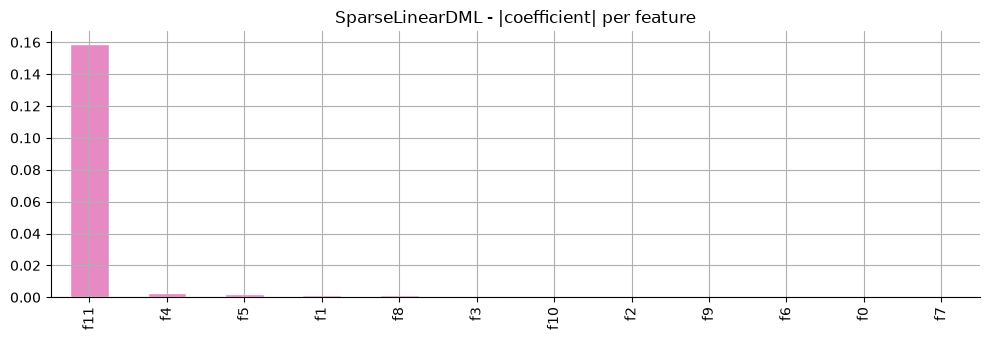

f11    0.158903
f4     0.002530
f5     0.001896
f1     0.001650
f8     0.001246
f3     0.000682
f10    0.000175
f2     0.000174
f9     0.000174
f6     0.000118
f0     0.000033
f7     0.000031
dtype: float64


In [7]:
coefs = sparse_dml.coef_
feat_names = [f'f{i}' for i in range(X_train.shape[1])]
fi = pd.Series(np.abs(coefs).flatten(), index=feat_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 3.5))
fi.plot.bar(ax=ax, color='#e78ac3', edgecolor='white')
ax.set_title('SparseLinearDML - |coefficient| per feature')
plt.tight_layout(); plt.savefig('sparse_dml_coefs.png', dpi=140); plt.show()
print(fi)

## Results

In [8]:
df = pd.DataFrame(results).T.astype(float).sort_values('Qini', ascending=False)
print('\n=== Leaderboard ===')
print(df.to_string(float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'))
df.style.background_gradient(subset=['AUUC','Qini','Uplift@10%','Uplift@20%'], cmap='Greens') \
        .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
        .format({'AUUC':'{:.6f}','Qini':'{:.6f}','Uplift@10%':'{:.4f}','Uplift@20%':'{:.4f}','Time(s)':'{:.1f}'})



=== Leaderboard ===
                    AUUC     Qini  Uplift@10%  Uplift@20%  Time(s)
SparseLinearDML 0.006249 0.185848    0.012500    0.005300    215.0
CausalForestDML 0.006150 0.182506    0.012000    0.006600     76.9
LinearDML       0.005682 0.169127    0.011300    0.005300     35.1


,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
SparseLinearDML,0.006249,0.185848,0.0125,0.0053,215.0
CausalForestDML,0.006150,0.182506,0.0120,0.0066,76.9
LinearDML,0.005682,0.169127,0.0113,0.0053,35.1


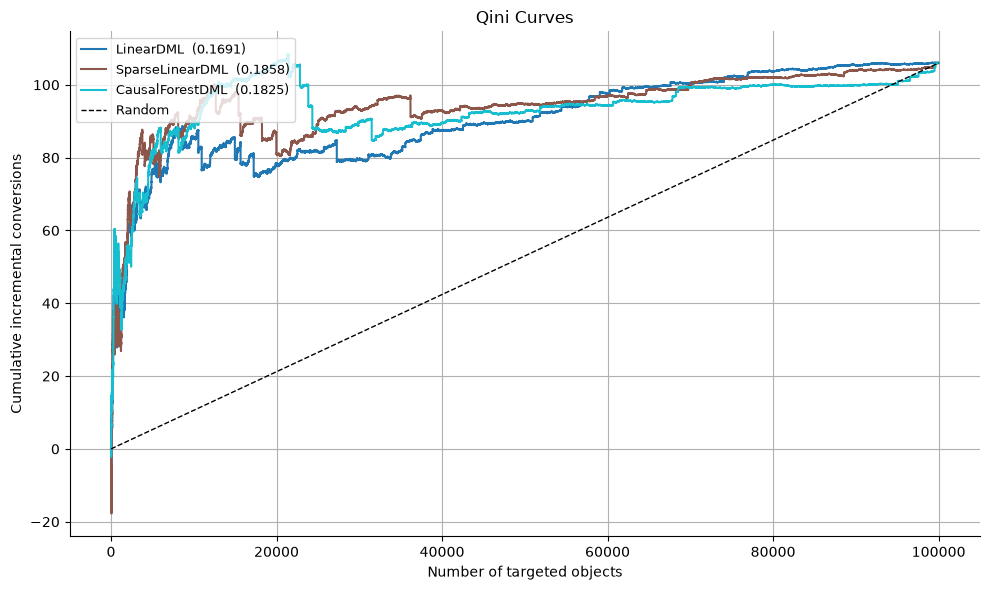

In [9]:
# Qini curves drawn by hand (see notebook 02): calling plot_qini_curve on a
# shared axis crashes on matplotlib >= 3.7.
from sklift.metrics import qini_curve
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(qini_curves)))
end = None
for (name, s), c in zip(qini_curves.items(), colors):
    x, y = qini_curve(y_test, np.asarray(s).flatten(), t_test)
    ax.plot(x, y, label=f'{name}  ({results[name]["Qini"]:.4f})', color=c)
    end = (x[-1], y[-1])
if end is not None:
    ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
ax.set_xlabel('Number of targeted objects')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Qini Curves')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{ARTIFACT_NAME}_qini.png', dpi=140, bbox_inches='tight'); plt.show()

In [10]:
# Persist results for the final benchmark notebook
os.makedirs('artifacts', exist_ok=True)
with open(f'artifacts/{ARTIFACT_NAME}.pkl', 'wb') as f:
    pickle.dump({'results': results, 'qini_curves': qini_curves,
                 'y_test': y_test, 't_test': t_test}, f)
print(f"Saved artifacts/{ARTIFACT_NAME}.pkl")


Saved artifacts/03_dml.pkl


## Summary

Overlap is clean on Criteo (notebook 00) and all variants use 5-fold cross-fitting, so the standard DML validity checks pass here.

Next: [04_advanced.ipynb](04_advanced.ipynb).